## Assignment 3

# Import libraries and dataset and common preprocessing steps

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import SGDRegressor

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [5]:
import os
print(os.listdir())

['ML_Assignment_01.ipynb', 'ML_Assignment_02.ipynb', 'ML_Assignment_03.ipynb']


In [6]:
# Option 3: Full absolute path (adjust for your system)
df = pd.read_csv("../../data/adult_income.csv")

In [7]:
print(df['income'].unique())

<ArrowStringArray>
[' <=50K', ' >50K', ' <=50K.', ' >50K.']
Length: 4, dtype: str


In [8]:
print(df.shape)

df.info()
df.isnull().sum()

(48842, 15)
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      48842 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48842 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.7 MB


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Question 1: Exploratory Data Analysis (EDA) -20
Problem Statement:
Find the three most important factors that separate individuals who earn more than $50K annually from those who earn $50K or less.
Tasks:
Perform EDA using appropriate charts and basic descriptive statistics.
Select your top 3 features and justify your choices using visual and statistical evidence.
For each selected feature, explain in simple terms why it intuitively affects income.
Rank your 3 features from most important to least important, provide why you think that ?


In [9]:
# Answer here question 1

df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


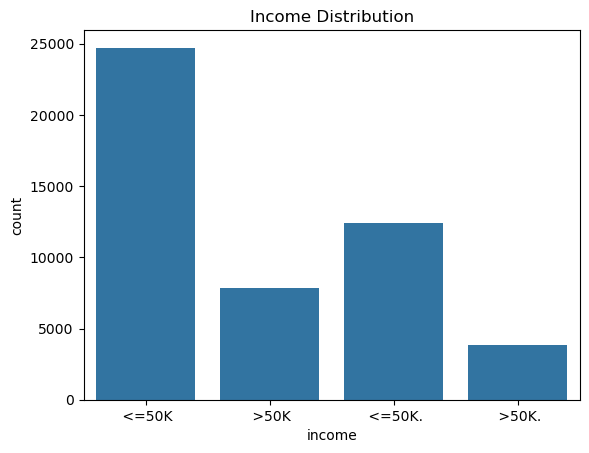

In [10]:
sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.show()

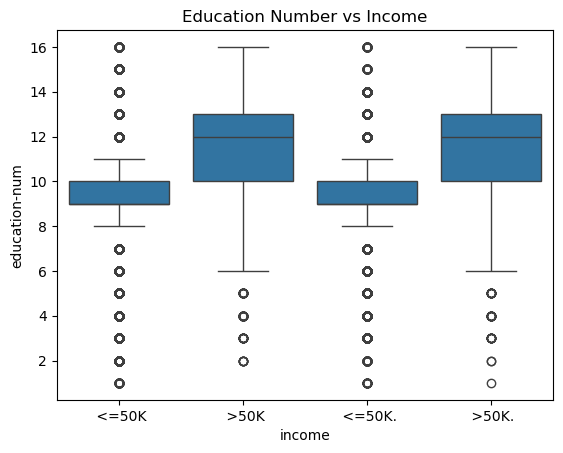

In [11]:
sns.boxplot(x='income', y='education-num', data=df)
plt.title("Education Number vs Income")
plt.show()

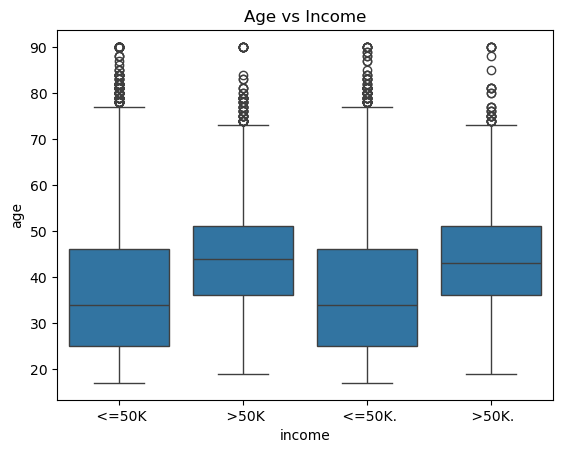

In [12]:
sns.boxplot(x='income', y='age', data=df)
plt.title("Age vs Income")
plt.show()

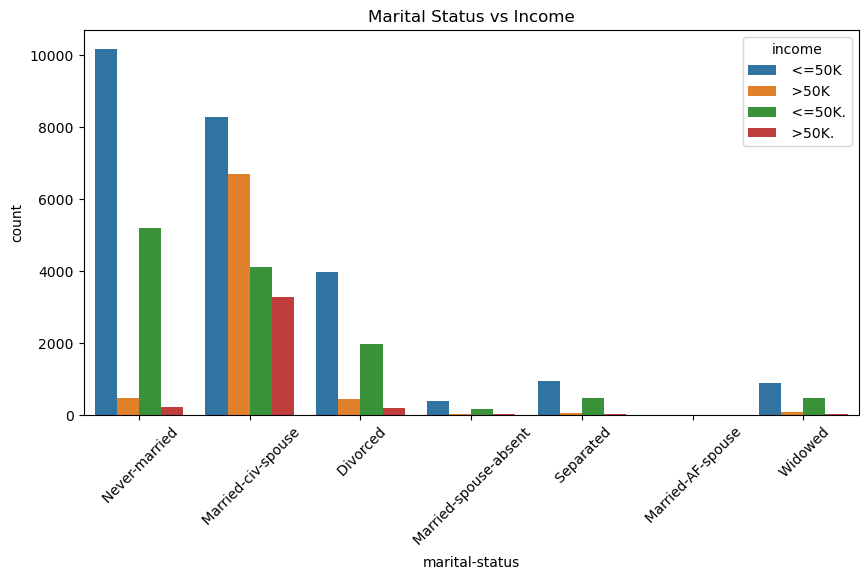

In [13]:
plt.figure(figsize=(10, 5))

sns.countplot(x='marital-status',
              hue='income',
              data=df)

plt.xticks(rotation=45)
plt.title("Marital Status vs Income")
plt.show()

In [14]:
df.groupby('income')['education-num'].mean()

income
<=50K      9.595065
<=50K.     9.605308
>50K      11.611657
>50K.     11.584763
Name: education-num, dtype: float64

In [15]:
df.groupby('income')['age'].mean()

income
<=50K     36.783738
<=50K.    37.048010
>50K      44.249841
>50K.     44.326833
Name: age, dtype: float64

In [16]:
pd.crosstab(df['marital-status'], df['income'])

income,<=50K,<=50K.,>50K,>50K.
marital-status,,,,
Divorced,3980,1982,463,208
Married-AF-spouse,13,10,10,4
Married-civ-spouse,8284,4111,6692,3292
Married-spouse-absent,384,186,34,24
Never-married,10192,5192,491,242
Separated,959,472,66,33
Widowed,908,482,85,43


Question 2: Preprocessing Pipeline Design (Regression) - 20
Problem Statement:
Predicting a continuous variable requires clean, properly formatted data. You will design a preprocessing pipeline to prepare the dataset for predicting hours-per-week based on the other available features.
Tasks:
Design Scikit-Learn Pipelines that handles missing values, categorical feature encoding, and numerical feature scaling.
Documentation: Clearly explain what specific preprocessing steps you applied to which columns and why you chose those specific methods.


In [17]:
# Answer here question 2

X = df.drop('hours-per-week', axis=1)
y = df['hours-per-week']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

num_cols = X.select_dtypes(include=['int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print(num_cols)
print(cat_cols)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='str')
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='str')


In [18]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [19]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

Question 3: Regression Modeling & Evaluation - 20
Problem Statement:
Utilizing the preprocessing pipeline designed in Question 2, train two different regression models to predict hours-per-week and evaluate their performance.
Tasks:
Train a standard Linear Regression model using your pipeline.
Train a Stochastic Gradient Descent (SGD) Regressor model using your pipeline.
Evaluate and compare both models using R2, MAE, and MSE.
Briefly discuss which model performed better and why.


In [21]:
# answer here question 3

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [22]:
print("Linear Regression Results")

print("R2 Score:",
      r2_score(y_test, y_pred_lr))

print("MAE:",
      mean_absolute_error(y_test, y_pred_lr))

print("MSE:",
      mean_squared_error(y_test, y_pred_lr))

Linear Regression Results
R2 Score: 0.20141926805365207
MAE: 7.657704386869741
MSE: 122.43679736527176


In [23]:
sgd_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(random_state=42))
])

sgd_model.fit(X_train, y_train)

y_pred_sgd = sgd_model.predict(X_test)

In [24]:
print("SGD Regressor Results")

print("R2 Score:",
      r2_score(y_test, y_pred_sgd))

print("MAE:",
      mean_absolute_error(y_test, y_pred_sgd))

print("MSE:",
      mean_squared_error(y_test, y_pred_sgd))

SGD Regressor Results
R2 Score: 0.20220786194799567
MAE: 7.640605395484654
MSE: 122.31589172983286


Question 4: Classification Pipeline & Error Analysis -20
Problem Statement:
Shift your focus from regression back to classification. Build an end-to-end Logistic Regression pipeline to predict whether a person earns more than $50K annually ( income feature)
Tasks:
Construct a new Scikit-Learn Pipeline that includes your new preprocessing steps and a Logistic Regression classifier.
Train the model and evaluate its performance on a test set using Accuracy, Precision, and Recall.


In [25]:
# answer here question 4

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
num_cols = X.select_dtypes(include=['int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [27]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [28]:
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [29]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred, average='weighted'))

print("Recall:",
      recall_score(y_test, y_pred, average='weighted'))

Accuracy: 0.5651550824035213
Precision: 0.45268598038317825
Recall: 0.5651550824035213


Question 5: Hyperparameter Tuning & Model Comparison
Problem Statement:
Train KNN model to classify income column. Determine if a distance based model like K-Nearest Neighbors (KNN) can outperform your Logistic Regression model when properly optimized.
Tasks:
Use GridSearchCV to systematically tune a KNN Classifier on hyperparameters: n_neighbors, weights, and metric.
Once the optimal KNN model is found, evaluate it using Accuracy, Precision, and Recall.
Comparison: Compare the performance metrics of your Tuned KNN model against the default Logistic Regression model. Which algorithm performed better overall.


In [30]:
# Answer here question 5

knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

In [31]:
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    knn_pipe,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__metric': ['euclidean', 'manhattan'], 'classifier__n_neighbors': [3, 5, ...], 'classifier__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [32]:
print(grid.best_params_)

{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}


In [33]:
best_knn = grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)

In [34]:
print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))

print("KNN Precision:",
      precision_score(y_test, y_pred_knn, pos_label=' >50K'))

print("KNN Recall:",
      recall_score(y_test, y_pred_knn, pos_label=' >50K'))

KNN Accuracy: 0.5198075545091616


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].